# Stress detection in human speech on the basis of convoulutional neural networks

installing and importing all the libraries, used for this work

In [ ]:
!pip install torchlibrosa torchcodec

In [ ]:
import os
import numpy as np
from tqdm import tqdm
import sys
import timm
import librosa

import torch
import torchaudio
import torchlibrosa
import torchcodec
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import  TensorDataset, Dataset, DataLoader, random_split

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import os
import numpy as np
import librosa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


### Dataset
For evaluating the performance of each model was used the
CRISIS expressive speech database, created to study Slovak
warning and soothing speech at several levels of tense arousal.
Recordings were made in triplets using a three-step method
that let the speaker reset to a neutral reference between
expressive levels, ensuring consistent emotional load.
For this work the middle arousal tiers were discarded,
merging recordings into a single “stress” class and into a
“relaxed” class.

**Link to the article:** [Alert! … Calm Down, There Is Nothing to Worry About.
Warning and Soothing Speech Synthesis](http://www.lrec-conf.org/proceedings/lrec2014/pdf/722_Paper.pdf)

## PANNs

downloading the model and it's checkpoint

In [ ]:
if not os.path.exists("/content/audioset_tagging_cnn"):
    !git clone https://github.com/qiuqiangkong/audioset_tagging_cnn.git

sys.path.append("/content/audioset_tagging_cnn/pytorch")
from models import Cnn14_no_specaug

Cloning into 'audioset_tagging_cnn'...
remote: Enumerating objects: 714, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 714 (delta 131), reused 120 (delta 120), pack-reused 560 (from 2)
Receiving objects: 100% (714/714), 3.99 MiB | 10.54 MiB/s, done.
Resolving deltas: 100% (412/412), done.


In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/Cnn14_16k_mAP=0.438.pth"
if not os.path.exists(CHECKPOINT_PATH):
    !wget https://zenodo.org/record/3987831/files/Cnn14_16k_mAP%3D0.438.pth

DATA_DIR = "/content/drive/MyDrive/STRESS_balanced"
classes = sorted(os.listdir(DATA_DIR))
print("Classes:", classes)

Classes: ['1', '2']


In [ ]:
model = Cnn14_no_specaug(
    sample_rate=16000,
    window_size=512,
    hop_size=160,
    mel_bins=64,
    fmin=50,
    fmax=14000,
    classes_num=527
)
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model"])
model.to(DEVICE)
model.eval()


/usr/local/lib/python3.12/dist-packages/torchlibrosa/stft.py:686: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  self.melW = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels,


Cnn14_no_specaug(
  (spectrogram_extractor): Spectrogram(
    (stft): STFT(
      (conv_real): Conv1d(1, 257, kernel_size=(512,), stride=(160,), bias=False)
      (conv_imag): Conv1d(1, 257, kernel_size=(512,), stride=(160,), bias=False)
    )
  )
  (logmel_extractor): LogmelFilterBank()
  (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_block1): ConvBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_block2): ConvBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): Bat

function to extract PANNs embeddings

In [ ]:
def get_embedding(output):
    if isinstance(output, dict):
        return output["embedding"]
    return output.embedding

embeddings_list = []
labels_list = []

for label_idx, cls in enumerate(classes):
    cls_path = os.path.join(DATA_DIR, cls)
    wav_files = [f for f in os.listdir(cls_path) if f.endswith(".wav")]

    print(f"Processing class {cls} ({label_idx+1}/{len(classes)})")

    for fname in wav_files:
        file_path = os.path.join(cls_path, fname)
        waveform, sr = torchaudio.load(file_path)

        # mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # resample
        if sr != 16000:
            waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

        # minimum length = 1s
        min_samples = 16000
        if waveform.shape[-1] < min_samples:
            waveform = torch.nn.functional.pad(
                waveform, (0, min_samples - waveform.shape[-1])
            )

        waveform = waveform.squeeze(0).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(waveform)
            embedding = get_embedding(output)

        embeddings_list.append(embedding.cpu())
        labels_list.append(label_idx)

embeddings = torch.cat(embeddings_list, dim=0)
labels = torch.tensor(labels_list)

print("Embeddings:", embeddings.shape)
print("Labels:", labels.shape)

torch.save(
    {"embeddings": embeddings, "labels": labels},
    "stress_embeddings.pt"
)

Processing class 1 (1/2)
Processing class 2 (2/2)
Embeddings: torch.Size([12974, 2048])
Labels: torch.Size([12974])


In [ ]:
X = embeddings.numpy()
y = labels.numpy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (9081, 2048)
Val:   (1946, 2048)
Test:  (1947, 2048)


Classification model for extracted embeddings

In [ ]:
num_classes = len(classes)

inputs = tf.keras.Input(shape=(2048,))
x = layers.Dense(256, activation="relu")(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

clf = models.Model(inputs, outputs)
clf.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

clf.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = clf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,698 (2.13 MB)

 Trainable params: 557,698 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
284/284 - 6s - 22ms/step - accuracy: 0.8608 - loss: 0.3258 - val_accuracy: 0.8993 - val_loss: 0.2503
Epoch 2/100
284/284 - 1s - 3ms/step - accuracy: 0.8911 - loss: 0.2594 - val_accuracy: 0.8993 - val_loss: 0.2539
Epoch 3/100
284/284 - 1s - 3ms/step - accuracy: 0.9071 - loss: 0.2336 - val_accuracy: 0.9111 - val_loss: 0.2169
Epoch 4/100
284/284 - 1s - 3ms/step - accuracy: 0.9095 - loss: 0.2262 - val_accuracy: 0.9188 - val_loss: 0.2084
Epoch 5/100
284/284 - 1s - 3ms/step - accuracy: 0.9118 - loss: 0.2190 - val_accuracy: 0.9142 - val_loss: 0.2200
Epoch 6/100
284/284 - 1s - 3ms/step - accuracy: 0.9094 - loss: 0.2232 - val_accuracy: 0.9111 - val_loss: 0.2118
Epoch 7/100
284/284 - 1s - 3ms/step - accuracy: 0.9149 - loss: 0.2031 - val_accuracy: 0.9044 - val_loss: 0.2353
Epoch 8/100
284/284 - 1s - 3ms/step - accuracy: 0.9169 - loss: 0.2094 - val_accuracy: 0.9132 - val_loss: 0.2291
Epoch 9/100
284/284 - 1s - 3ms/step - accuracy: 0.9162 - loss: 0.2071 - val_accuracy: 0.9101 - val_loss

## PANNs results displaying


In [ ]:
y_pred_prob = clf.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}\n")

print(classification_report(y_test, y_pred, target_names=classes))

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy:  0.9414
Precision: 0.9417
Recall:    0.9414
F1-score:  0.9414

              precision    recall  f1-score   support

           1       0.93      0.95      0.94       974
           2       0.95      0.93      0.94       973

    accuracy                           0.94      1947
   macro avg       0.94      0.94      0.94      1947
weighted avg       0.94      0.94      0.94      1947



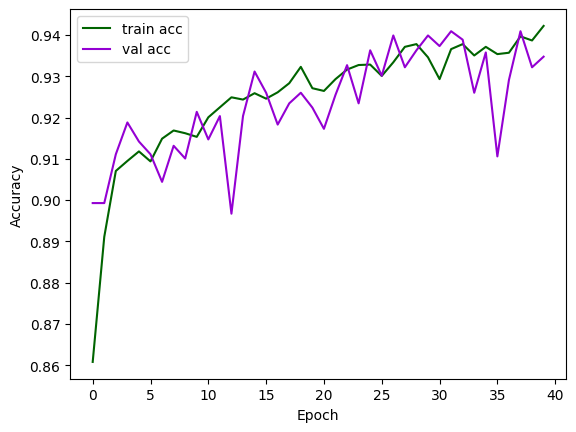

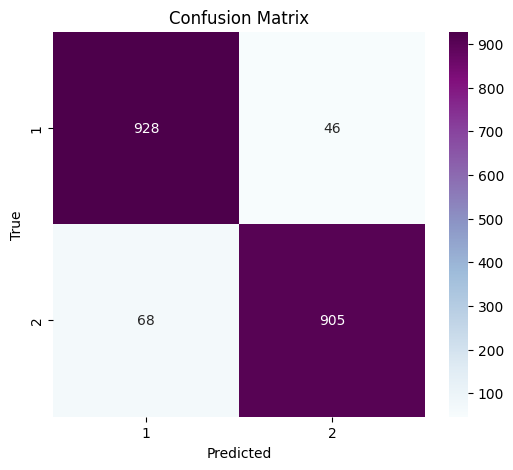

In [ ]:
plt.figure()
plt.plot(history.history["accuracy"], label="train acc", color = "darkgreen")
plt.plot(history.history["val_accuracy"], label="val acc", color = "darkviolet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="BuPu",
    xticklabels=classes, yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## YAMNET

downloading the model and extractiong the embeddings

In [ ]:
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")

def get_yamnet_embedding(file_path):
    waveform, sr = librosa.load(file_path, sr=16000, mono=True)
    waveform = waveform.astype(np.float32)
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return tf.reduce_mean(embeddings, axis=0).numpy()


In [ ]:
all_embeddings = []
all_labels = []

for label_idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    wav_files = [f for f in os.listdir(cls_dir) if f.endswith(".wav")]

    print(f"Processing class {cls}")
    for f in tqdm(wav_files):
        path = os.path.join(cls_dir, f)
        try:
            emb = get_yamnet_embedding(path)
            all_embeddings.append(emb)
            all_labels.append(label_idx)
        except Exception as e:
            print("Error:", path, e)

X = np.stack(all_embeddings)   # (N, 1024)
y = np.array(all_labels)

Processing class 1


100%|██████████| 6487/6487 [02:07<00:00, 51.02it/s] 


Processing class 2


100%|██████████| 6487/6487 [01:54<00:00, 56.84it/s] 


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


Building classifier


In [ ]:
num_classes = len(classes)
inputs = tf.keras.Input(shape=(1024,))
x = layers.Dense(256, activation="relu")(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/100
284/284 - 5s - 17ms/step - accuracy: 0.8724 - loss: 0.3216 - val_accuracy: 0.8962 - val_loss: 0.2597
Epoch 2/100
284/284 - 1s - 3ms/step - accuracy: 0.8954 - loss: 0.2581 - val_accuracy: 0.9147 - val_loss: 0.2192
Epoch 3/100
284/284 - 1s - 3ms/step - accuracy: 0.9079 - loss: 0.2327 - val_accuracy: 0.8983 - val_loss: 0.2517
Epoch 4/100
284/284 - 1s - 3ms/step - accuracy: 0.9127 - loss: 0.2210 - val_accuracy: 0.9291 - val_loss: 0.1873
Epoch 5/100
284/284 - 1s - 3ms/step - accuracy: 0.9171 - loss: 0.2137 - val_accuracy: 0.9270 - val_loss: 0.1852
Epoch 6/100
284/284 - 1s - 3ms/step - accuracy: 0.9212 - loss: 0.2032 - val_accuracy: 0.9260 - val_loss: 0.1849
Epoch 7/100
284/284 - 1s - 3ms/step - accuracy: 0.9257 - loss: 0.1979 - val_accuracy: 0.9178 - val_loss: 0.2085
Epoch 8/100
284/284 - 1s - 4ms/step - accuracy: 0.9243 - loss: 0.1939 - val_accuracy: 0.9229 - val_loss: 0.1927
Epoch 9/100
284/284 - 1s - 4ms/step - accuracy: 0.9249 - loss: 0.1874 - val_accuracy: 0.9327 - val_loss

## YAMNet results displaying

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}\n")

print(classification_report(y_test, y_pred, target_names=classes))


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy : 0.9522
Precision: 0.9526
Recall   : 0.9522
F1-score : 0.9522

              precision    recall  f1-score   support

           1       0.94      0.97      0.95       974
           2       0.97      0.94      0.95       973

    accuracy                           0.95      1947
   macro avg       0.95      0.95      0.95      1947
weighted avg       0.95      0.95      0.95      1947



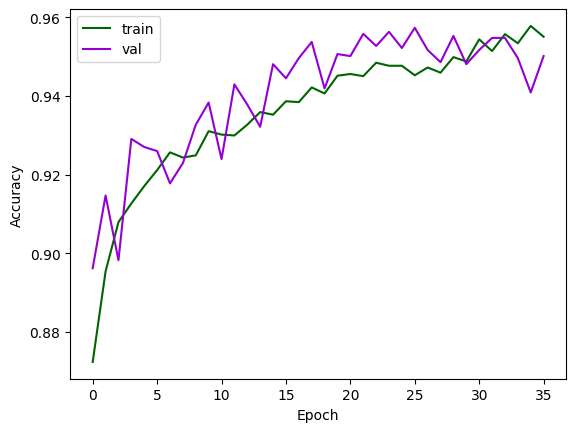

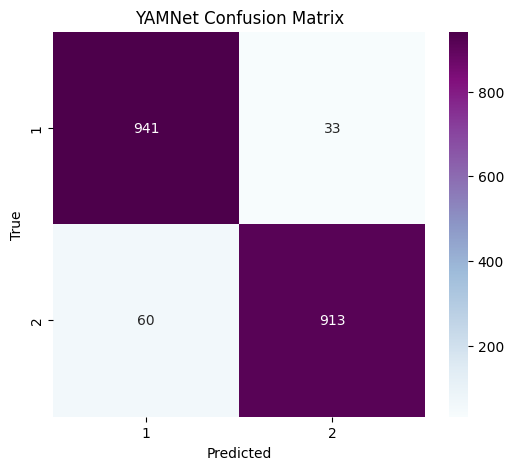

In [ ]:
plt.plot(history.history["accuracy"], label="train", color = "darkgreen")
plt.plot(history.history["val_accuracy"], label="val", color = "darkviolet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuPu",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("YAMNet Confusion Matrix")
plt.show()

## CNN-LSTM

Generating spectrograms out of dataset recordings in a similar way as it is done in pretrained extractors

In [ ]:
SAMPLE_RATE = 16000
N_MELS = 64
HOP_LENGTH = 320
WINDOW_SIZE = 1024
FMIN = 50
FMAX = 14000

X = []
y = []

for label_idx, cls in enumerate(classes):
    folder = os.path.join(DATA_DIR, cls)
    wav_files = [f for f in os.listdir(folder) if f.endswith(".wav")]

    for fname in wav_files:
        path = os.path.join(folder, fname)

        waveform, sr = librosa.load(path, sr=SAMPLE_RATE)

        mel = librosa.feature.melspectrogram(
            y=waveform,
            sr=SAMPLE_RATE,
            n_fft=WINDOW_SIZE,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
        )
        logmel = librosa.power_to_db(mel)

        X.append(logmel)     # shape: (n_mels, time)
        y.append(label_idx)

y = np.array(y)
print("Loaded samples:", len(X))
print("Example shape:", X[0].shape)


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Loaded samples: 12974
Example shape: (64, 165)


Downloading pretrained CNN feature extracting model

In [ ]:

model = timm.create_model(
    "tf_efficientnetv2_s.in21k",
    pretrained=True,
    num_classes=0,      # removes classifier, outputs embeddings
    global_pool="avg"   # 1280-D embedding
).to(DEVICE)

model.eval()

# resolution EfficientNetV2 expects:
TARGET_SIZE = 384


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/193M [00:00<?, ?B/s]

Converting spectrograms to right format for extractor


In [ ]:
def spec_to_embedding(logmel):
    # logmel shape: (n_mels, time)

    # Normalize to 0–1
    img = (logmel - logmel.min()) / (logmel.max() - logmel.min() + 1e-9)

    # Convert to torch tensor
    img = torch.tensor(img, dtype=torch.float32)

    # Resize to EfficientNet input size
    img = F.interpolate(
        img.unsqueeze(0).unsqueeze(0),
        size=(TARGET_SIZE, TARGET_SIZE),
        mode="bilinear",
        align_corners=False
    ).squeeze()

    # Make it 3-channel
    img3 = img.repeat(3, 1, 1)

    # Add batch dimension
    img3 = img3.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        emb = model(img3)

    return emb.cpu().numpy().squeeze()


In [ ]:
embeddings = []

for i in tqdm(range(len(X))):
    logmel = X[i]
    emb = spec_to_embedding(logmel)
    embeddings.append(emb)

embeddings = np.array(embeddings)

print("Final embedding shape:", embeddings.shape)
print("Labels shape:", y.shape)

np.save("/content/drive/MyDrive/STRESS_embeddings.npy", embeddings)
np.save("/content/drive/MyDrive/STRESS_labels.npy", y)

print("Embeddings and labels saved!")

100%|██████████| 12974/12974 [04:21<00:00, 49.54it/s]


Final embedding shape: (12974, 1280)
Labels shape: (12974,)
Embeddings and labels saved!


In [ ]:
X = torch.tensor(embeddings, dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.long)  # classification labels

dataset = TensorDataset(X, y)

# Split: 70% train, 15% val, 15% test
N = len(dataset)
train_size = int(0.7 * N)
val_size = int(0.15 * N)
test_size = N - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

/tmp/ipython-input-1918842521.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(labels, dtype=torch.long)  # classification labels


Building LSTM layers

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=1280, hidden_dim=256, num_layers=2, num_classes=2, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # LSTM expects (batch, seq_len, input_dim)
        x = x.unsqueeze(1)
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

num_classes = len(np.unique(labels))
model = LSTMClassifier(num_classes=num_classes)


In [ ]:
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 100
patience = 10

best_val_acc = 0.0
epochs_no_improve = 0
best_model_state = None

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += yb.size(0)
        correct += (predicted == yb).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += yb.size(0)
            correct += (predicted == yb).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / total

    # ---------- SAVE HISTORY ----------
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    # ---------- EARLY STOPPING ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# ---------- RESTORE BEST MODEL ----------
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Restored best model weights.")


Epoch 1/100 | Train Loss: 0.3178, Train Acc: 0.8668 | Val Loss: 0.2821, Val Acc: 0.8839
Epoch 2/100 | Train Loss: 0.2337, Train Acc: 0.9057 | Val Loss: 0.2187, Val Acc: 0.9168
Epoch 3/100 | Train Loss: 0.2088, Train Acc: 0.9179 | Val Loss: 0.1889, Val Acc: 0.9317
Epoch 4/100 | Train Loss: 0.1914, Train Acc: 0.9231 | Val Loss: 0.1872, Val Acc: 0.9409
Epoch 5/100 | Train Loss: 0.1728, Train Acc: 0.9325 | Val Loss: 0.2074, Val Acc: 0.9224
Epoch 6/100 | Train Loss: 0.1632, Train Acc: 0.9372 | Val Loss: 0.1805, Val Acc: 0.9301
Epoch 7/100 | Train Loss: 0.1558, Train Acc: 0.9400 | Val Loss: 0.1523, Val Acc: 0.9476
Epoch 8/100 | Train Loss: 0.1569, Train Acc: 0.9391 | Val Loss: 0.1572, Val Acc: 0.9460
Epoch 9/100 | Train Loss: 0.1444, Train Acc: 0.9427 | Val Loss: 0.1554, Val Acc: 0.9430
Epoch 10/100 | Train Loss: 0.1373, Train Acc: 0.9470 | Val Loss: 0.1617, Val Acc: 0.9419
Epoch 11/100 | Train Loss: 0.1290, Train Acc: 0.9507 | Val Loss: 0.1531, Val Acc: 0.9491
Epoch 12/100 | Train Loss: 0.1

## CNN-LSTM results displaying

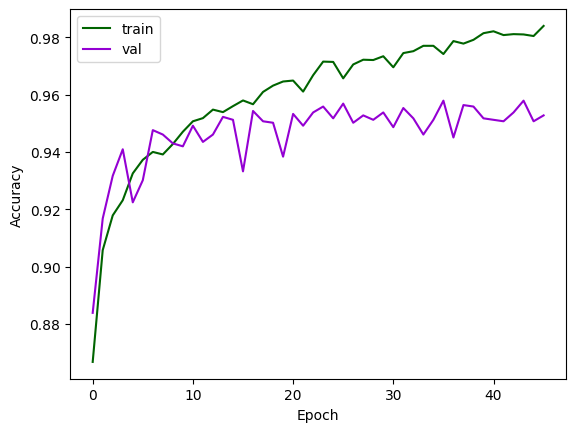

In [ ]:
plt.plot(history["train_acc"], label="train", color = "darkgreen")
plt.plot(history["val_acc"], label="val", color = "darkviolet")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Accuracy : 0.9553
Precision: 0.9558
Recall   : 0.9550
F1-score : 0.9553

              precision    recall  f1-score   support

           1       0.95      0.97      0.96       996
           2       0.97      0.94      0.95       951

    accuracy                           0.96      1947
   macro avg       0.96      0.96      0.96      1947
weighted avg       0.96      0.96      0.96      1947



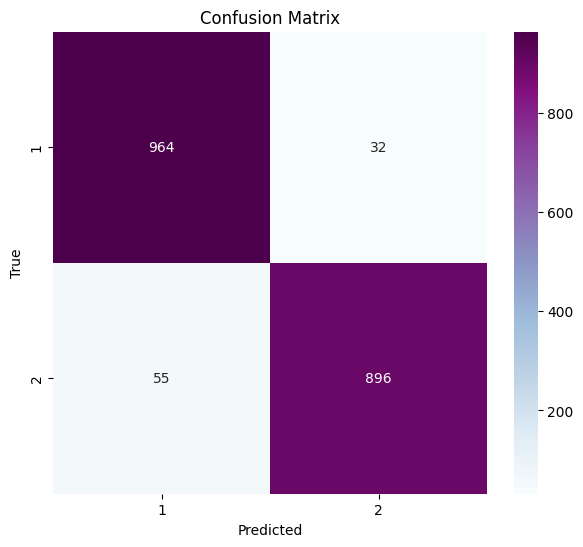

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

# Flatten lists
y_pred = np.concatenate(all_preds)
y_test = np.concatenate(all_labels)


acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}\n")

print(classification_report(y_test, y_pred, target_names=classes))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
